- **학습 목표**: 베이즈 정리를 외운 공식이 아니라, 구체적 숫자로 직접 계산해 직관을 얻는다.
- **핵심 개념**: `P(A|B) = P(B|A)·P(A) / P(B)`. 분모 `P(B)`는 전체확률의 법칙으로 분해합니다. 사전확률(prior)이 낮으면, 검사가 아무리 정확해도 사후확률은 생각보다 낮습니다.

In [2]:
import numpy as np
from matplotlib import pyplot as plt

0.16666666666666669


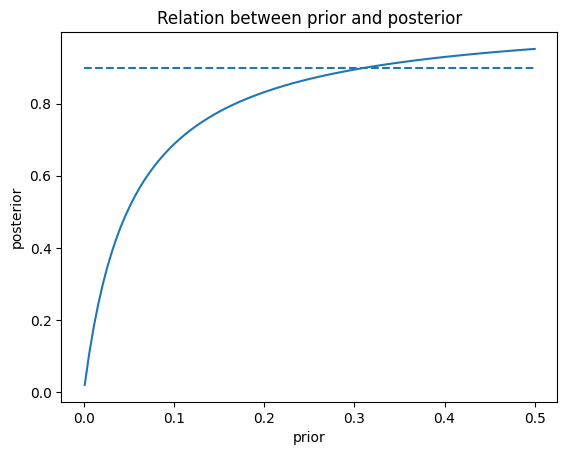

In [16]:
def bayes_posterior(prior: float, sensitivity: float, false_positive_rate: float) -> float:
  """
  요구사항:
  - 전체확률의 법칙으로 P(양성)을 계산한 뒤 사후확률을 반환한다.
  - 손으로 계산한 값과 소수점 4자리까지 일치하는지 확인할 것.
  - 추가: prior를 0.001 ~ 0.5로 바꿔가며 사후확률이 어떻게 변하는지
    그래프로 그려볼 것.
  """

  positive_rate = prior*sensitivity+(1-prior)*false_positive_rate
  posterior = prior*sensitivity/positive_rate
  return posterior
prior = 0.01
sensitivity = 0.99
false_positive_rate = 0.05
posterior = bayes_posterior(prior, sensitivity, false_positive_rate)
print(posterior)
prior = np.linspace(0.001, 0.5, 100)
posterior = bayes_posterior(prior, sensitivity, false_positive_rate)
plt.figure()
plt.plot(prior, posterior)
plt.xlabel('prior')
plt.ylabel('posterior')
plt.title('Relation between prior and posterior')
plt.hlines(0.9,0,0.5, linestyles='dashed')
plt.show()

- **학습 목표**: "우도를 최대화한다"는 말의 의미를 동전 던지기로 이해하고, 왜 로그를 씌우는지 스스로 설명할 수 있다.
- **핵심 개념**: 우도(likelihood)는 "파라미터가 이 값일 때 관측된 데이터가 나올 확률"입니다. MLE는 그 값을 최대로 만드는 파라미터를 고르는 것입니다. 로그는 단조증가 함수라 argmax를 바꾸지 않으면서 곱을 합으로 바꿔줍니다.

In [1]:
from scipy.stats import binom

argmax: 0.49555555555555564, k/n: 0.5


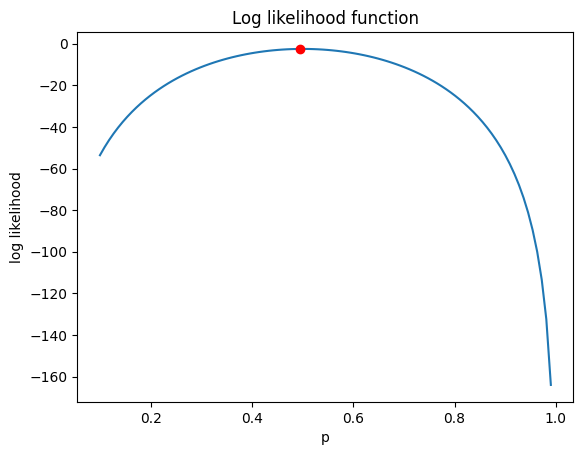

In [6]:
def log_likelihood(p: float, n: int, k: int) -> float:
  """이항분포의 로그우도. p가 0 또는 1이면 -inf 반환."""
  if p == 0 or p == 1:
    return -np.inf
  return binom.logpmf(k, n, p)

def find_mle_numerically(n: int, k: int):
  """
  요구사항:
  - p를 0.01~0.99로 촘촘히 훑으며 로그우도를 계산한다.
  - argmax인 p를 찾아 이론값 k/n과 비교 출력한다.
  - 로그우도 곡선과 argmax 위치를 그려 'week03/mle_coin_flip.png'로 저장.
  """
  p = np.linspace(0.1, 0.99, 100)
  log_likelihoods = [log_likelihood(p_i, n, k) for p_i in p]
  argmax = p[np.argmax(log_likelihoods)]

  print(f'argmax: {argmax}, k/n: {k/n}')
  plt.figure()

  plt.plot(p, log_likelihoods)
  plt.plot(argmax, log_likelihoods[np.argmax(log_likelihoods)], 'ro')
  plt.xlabel('p')
  plt.ylabel('log likelihood')
  plt.title('Log likelihood function')
  plt.show()
find_mle_numerically(100, 50)